The Nobel Prize has been among the most prestigious international awards since 1901. Each year, awards are bestowed in chemistry, literature, physics, physiology or medicine, economics, and peace. In addition to the honor, prestige, and substantial prize money, the recipient also gets a gold medal with an image of Alfred Nobel (1833 - 1896), who established the prize.

![](Nobel_Prize.png)

The Nobel Foundation has made a dataset available of all prize winners from the outset of the awards from 1901 to 2023. The dataset used in this project is from the Nobel Prize API and is available in the `nobel.csv` file in the `data` folder.

In this project, you'll get a chance to explore and answer several questions related to this prizewinning data. And we encourage you then to explore further questions that you're interested in!

In [209]:
# Loading in required libraries
import pandas as pd
import seaborn as sns
import numpy as np

In [210]:
# Loading data as DataFrame

df = pd.read_csv('data/nobel.csv')

df.head()

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


In [211]:
# Which gender has recieved the most amounts of awards?
top_gender = df.value_counts('sex').index[0]
print(top_gender)

Male


In [212]:
# Display the number of (possibly shared) Nobel Prizes handed between 1901 and 2016
display(len(df))

# Display the number of prizes won by male and female recipients.
display(df['sex'].value_counts())

# Display the number of prizes won by the top 10 nationalities.
df['birth_country'].value_counts().head(10)

1000

Male      905
Female     65
Name: sex, dtype: int64

United States of America    291
United Kingdom               91
Germany                      67
France                       58
Sweden                       30
Japan                        28
Canada                       21
Switzerland                  19
Netherlands                  19
Italy                        18
Name: birth_country, dtype: int64

In [213]:
# Which nation represents the highest amount of award winners?

top_country = df.value_counts('birth_country').index[0]
print(top_country)

United States of America


In [214]:
df['US_born'] = df['birth_country'] == 'United States of America'

df['decade'] = df['year'].apply(lambda x: (x // 10) * 10)
print(df['decade'])

df_decade_ratio = df.groupby('decade')['US_born'].mean().reset_index()
print(df_decade_ratio)

# To get the decade with the highest US_born ratio, use idxmax and then get the decade value
max_decade_usa = df_decade_ratio.loc[df_decade_ratio['US_born'].idxmax(), 'decade']
print(most_wins_decade)

0      1900
1      1900
2      1900
3      1900
4      1900
       ... 
995    2020
996    2020
997    2020
998    2020
999    2020
Name: decade, Length: 1000, dtype: int64
    decade   US_born
0     1900  0.017544
1     1910  0.075000
2     1920  0.074074
3     1930  0.250000
4     1940  0.302326
5     1950  0.291667
6     1960  0.265823
7     1970  0.317308
8     1980  0.319588
9     1990  0.403846
10    2000  0.422764
11    2010  0.314050
12    2020  0.360000
2000


In [215]:
df['us_born_winner'] = df['birth_country'] == 'United States of America'

df['decade'] = df['year'].apply(lambda x: (x // 10) * 10)
print(df['decade'])

us_winners_ratio = df.groupby('decade')['us_born_winner'].mean().reset_index()
print(df_decade_ratio)

# To get the decade with the highest US_born ratio, use idxmax and then get the decade value
max_decade_usa = us_winners_ratio.loc[us_winners_ratio['us_born_winner'].idxmax(), 'decade']
print(most_wins_decade)

0      1900
1      1900
2      1900
3      1900
4      1900
       ... 
995    2020
996    2020
997    2020
998    2020
999    2020
Name: decade, Length: 1000, dtype: int64
    decade   US_born
0     1900  0.017544
1     1910  0.075000
2     1920  0.074074
3     1930  0.250000
4     1940  0.302326
5     1950  0.291667
6     1960  0.265823
7     1970  0.317308
8     1980  0.319588
9     1990  0.403846
10    2000  0.422764
11    2010  0.314050
12    2020  0.360000
2000


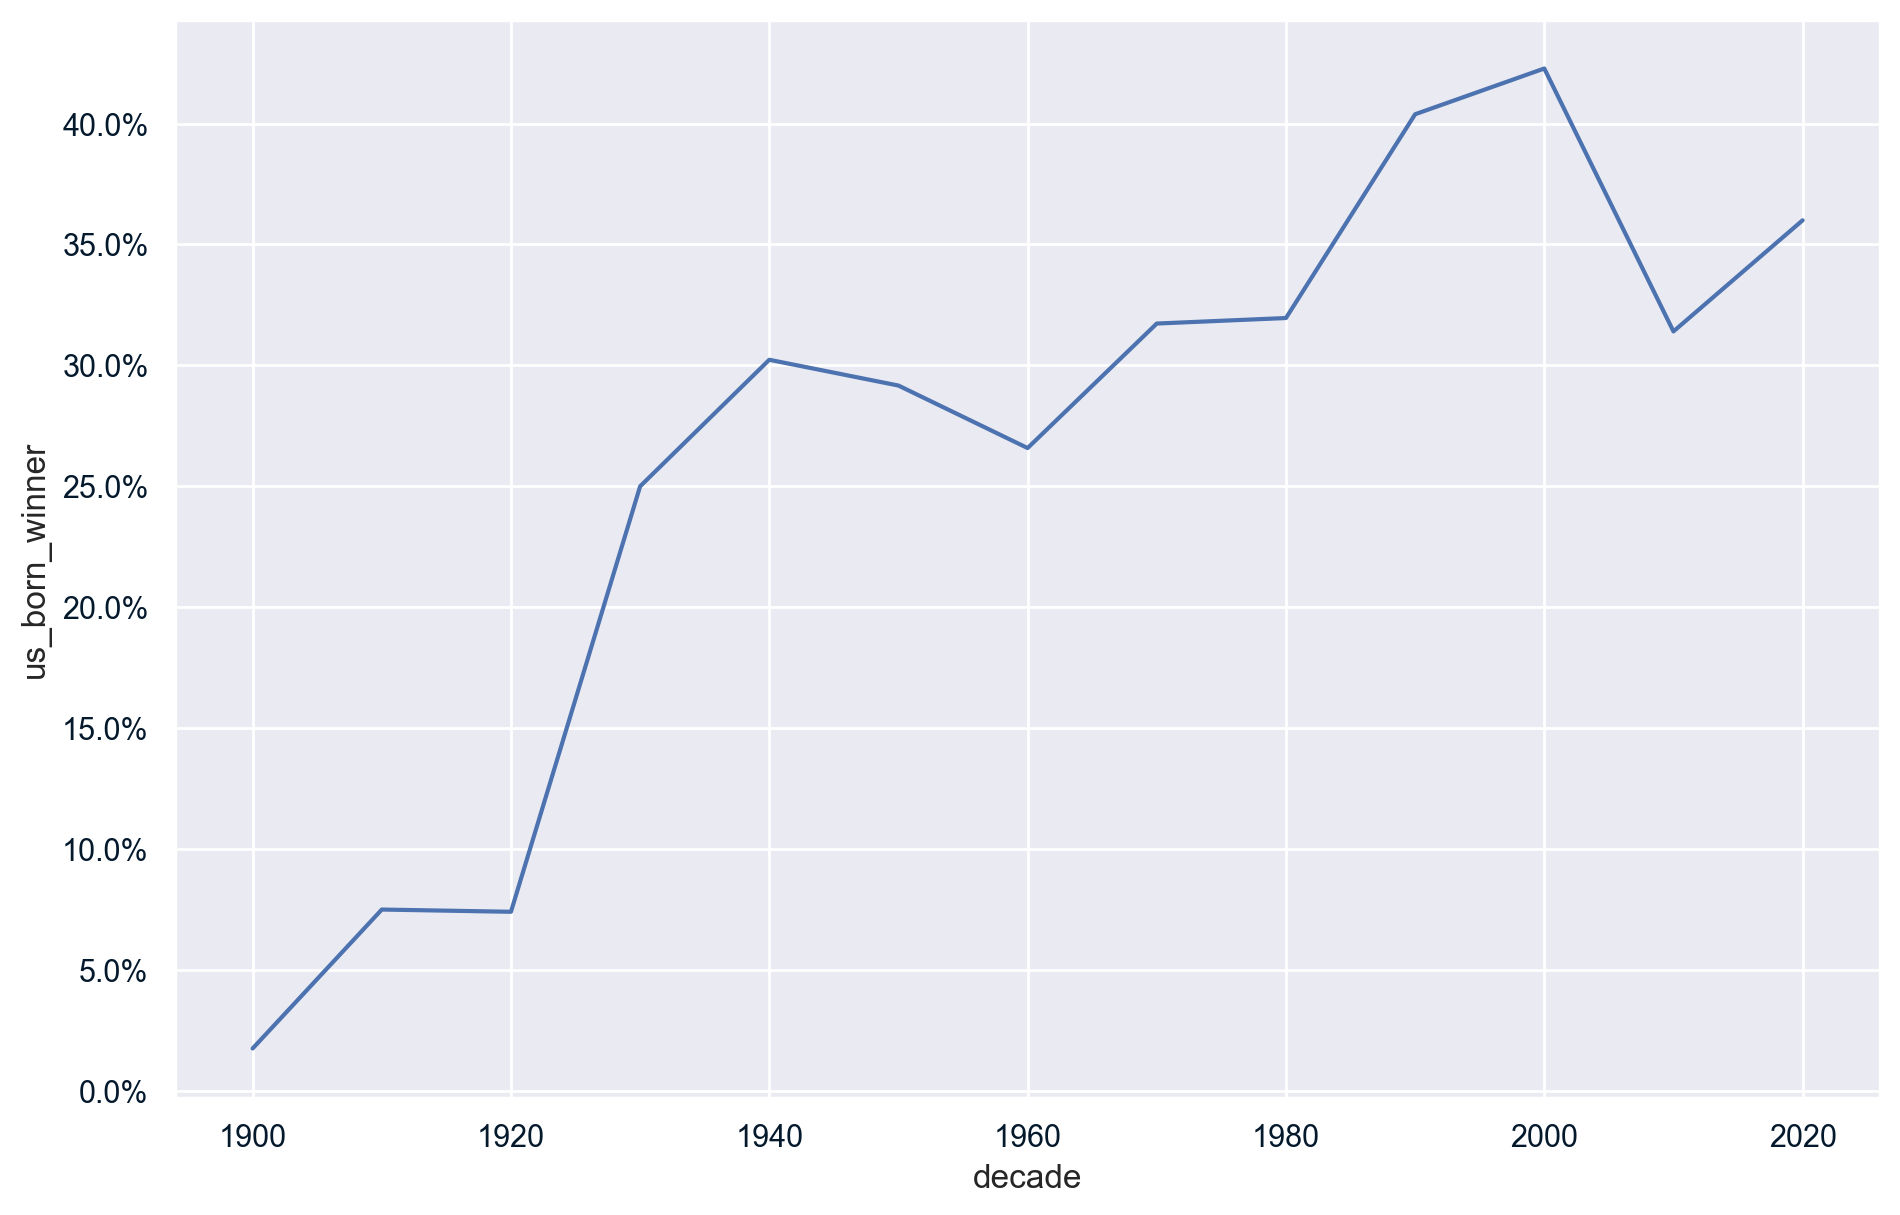

In [216]:
# Setting the plotting theme
sns.set()
# and setting the size of all plots.
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [11, 7]

# Plotting USA born winners 
ax = sns.lineplot(x='decade', y='us_born_winner', data = us_winners_ratio)

# Adding %-formatting to the y-axis
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

{2020: 'Literature'}


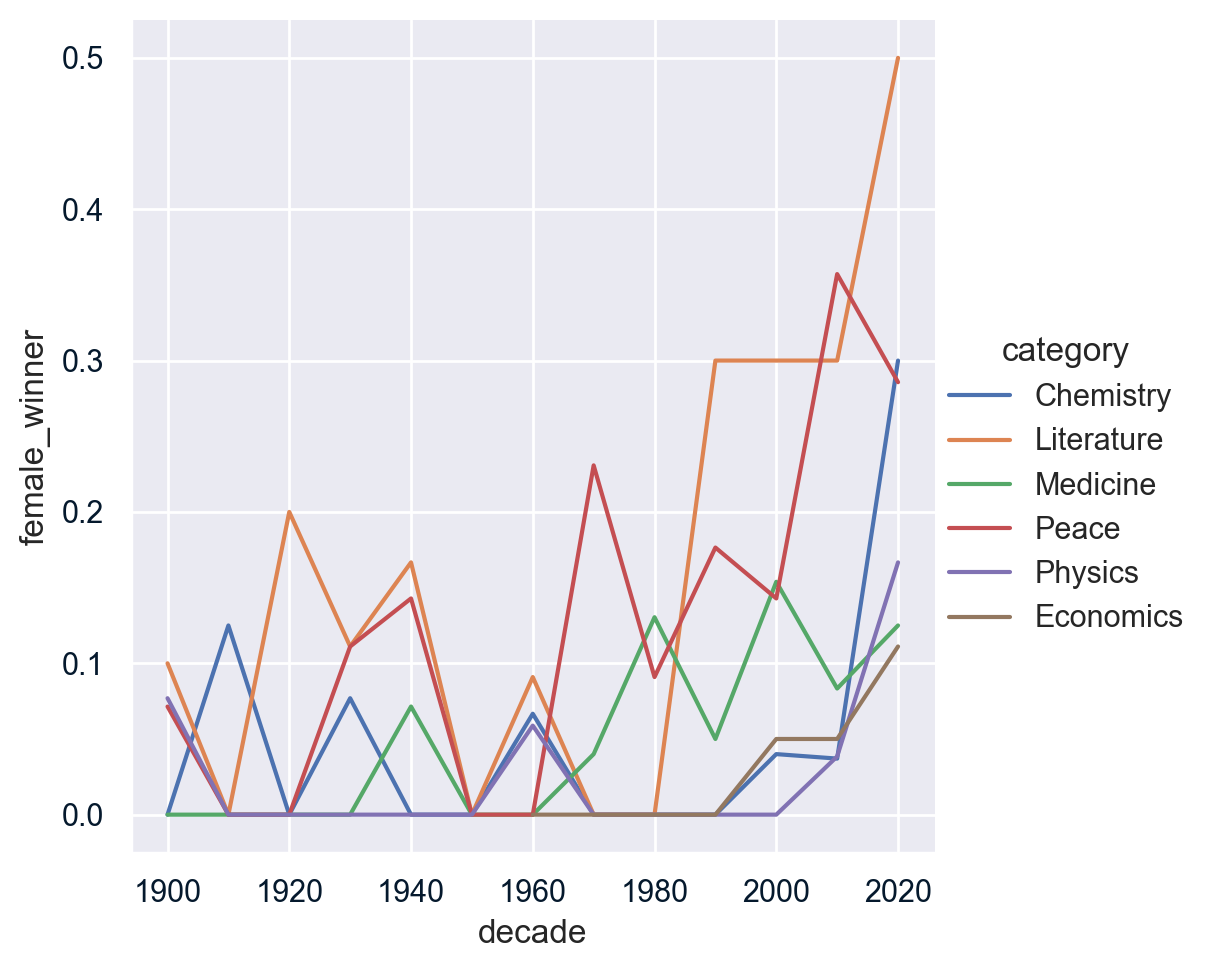

In [217]:
df['female_winner'] = df['sex'] == 'Female'
df_female = df.groupby(['decade', 'category'], as_index = False)['female_winner'].mean()

# Find the decade and category with the highest proportion of female laureates
df_female_max = df_female[df_female['female_winner'] == df_female['female_winner'].max()][['decade', 'category']]

# Create a dictionary with the decade and category pair
max_female_dict = {df_female_max['decade'].values[0]: df_female_max['category'].values[0]}
print(max_female_dict)

ax2 = sns.relplot(x='decade', y='female_winner', hue='category', data = df_female, kind="line")

In [218]:
female_winners = df[df['female_winner']]
min_row = female_winners[female_winners['sex'] == 'Female'].nsmallest(1, 'year')

# Extracting the name and category of the first female Nobel Prize winner
first_woman_name = female_winners['full_name'].values[0]
first_woman_category = female_winners['category'].values[0]

# Printing the name of category of the first female Nobel Prize winner
print(f"\n The first woman to win the Noble Prize in {first_woman_category} is {first_woman_name}")

repeats = (df['full_name'].value_counts().loc[lambda s: s >= 2].index)
repeat_list = list(repeats)

print(f"\n The winners of two or more Nobel Prizes are: {repeat_list}")


 The first woman to win the Noble Prize in Physics is Marie Curie, née Sklodowska

 The winners of two or more Nobel Prizes are: ['Comité international de la Croix Rouge (International Committee of the Red Cross)', 'Linus Carl Pauling', 'John Bardeen', 'Frederick Sanger', 'Marie Curie, née Sklodowska', 'Office of the United Nations High Commissioner for Refugees (UNHCR)']
